### Loading Data

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.stats import linregress

In [37]:
df=pd.read_csv("n3lo_450_lg1_eos.csv")
df.head()

,T [MeV],n_B [1/fm3],Y_Q,mu_B [MeV],f [MeV/fm3],e [MeV/fm3],p [MeV/fm3],s [1/fm3]
0,0.0,0.0016,0.5,-0.316932,-0.000055,-0.001697,-0.000503,0.0
1,0.0,0.0032,0.5,-1.021325,-0.001118,-0.006330,-0.002073,0.0
2,0.0,0.0048,0.5,-1.735767,-0.003321,-0.013567,-0.004940,0.0
3,0.0,0.0064,0.5,-2.435262,-0.006656,-0.023205,-0.008858,0.0
4,0.0,0.0080,0.5,-3.114105,-0.011094,-0.035097,-0.013744,0.0


In [38]:
temps=sorted(df["T [MeV]"].unique())
selected = [0,5,10,15,20,25]

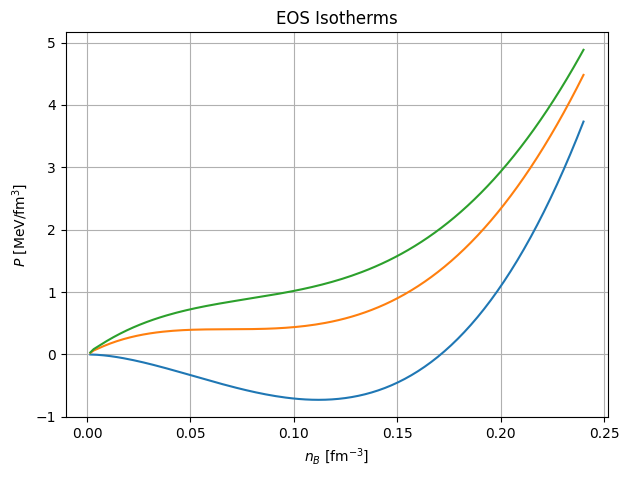

In [39]:
plt.figure(figsize=(7,5))

for T in temps:
    if T==0 or T==19 or T==25:
        subset = df[df["T [MeV]"]==T]
    
        plt.plot(
            subset["n_B [1/fm3]"],
            subset["p [MeV/fm3]"],
            label=f"T={T}"
        )

plt.xlabel(r"$n_B$ [fm$^{-3}$]")
plt.ylabel(r"$P$ [MeV/fm$^3$]")
plt.title("EOS Isotherms")
plt.grid()
plt.show()

### Identifying Critical Point

In [40]:
results = []

for T in temps:

    subset = df[df["T [MeV]"] == T].copy()

    subset = subset.sort_values("n_B [1/fm3]")

    n = subset["n_B [1/fm3]"].values
    P = subset["p [MeV/fm3]"].values

    dPdn = np.gradient(P, n)
    d2Pdn2 = np.gradient(dPdn, n)

    # Distance from critical-point conditions
    score = np.sqrt(dPdn**2 + d2Pdn2**2)

    idx = np.argmin(score)

    results.append({
        "T": T,
        "n": n[idx],
        "P": P[idx],
        "dPdn": dPdn[idx],
        "d2Pdn2": d2Pdn2[idx],
        "score": score[idx]
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("score")

print(results_df.head())

        T       n         P      dPdn    d2Pdn2     score
96   19.2  0.0688  0.418242  0.277694 -0.287385  0.399630
91   18.2  0.0672  0.349882 -0.508151 -0.888229  1.023312
101  20.2  0.0704  0.490475  1.085719  0.123949  1.092771
90   18.0  0.0672  0.336459 -0.662888  0.971738  1.176306
85   17.0  0.0656  0.272618 -1.422570 -0.133119  1.428785


In [41]:
from scipy.interpolate import interp1d
from scipy.optimize import brentq

temps = np.sort(df["T [MeV]"].unique())

results = []

for T in temps:

    sub = df[df["T [MeV]"] == T].sort_values("n_B [1/fm3]")

    n = sub["n_B [1/fm3]"].values
    P = sub["p [MeV/fm3]"].values

    dPdn = np.gradient(P, n)

    idx = np.argmin(dPdn)

    results.append([
        T,
        dPdn[idx],
        n[idx]
    ])

results = pd.DataFrame(
    results,
    columns=[
        "T",
        "min_dPdn",
        "n_at_min"
    ]
)

print(results.head())

     T  min_dPdn  n_at_min
0  0.0 -9.521327    0.0512
1  0.2 -9.591247    0.0544
2  0.4 -9.747893    0.0496
3  0.6 -9.731270    0.0512
4  0.8 -9.592389    0.0512


In [42]:
mins = results["min_dPdn"].values
Ts = results["T"].values

crossings = np.where(
    np.diff(np.sign(mins))
)[0]

print("Crossings:", crossings)

i = crossings[0]

T1 = Ts[i]
T2 = Ts[i+1]

y1 = mins[i]
y2 = mins[i+1]

Tc = T1 + (-y1)*(T2-T1)/(y2-y1)

print("Tc =", Tc)

Crossings: [94]
Tc = 18.84855866577679


In [43]:
n1 = results.iloc[i]["n_at_min"]
n2 = results.iloc[i+1]["n_at_min"]

nc = n1 + (Tc - T1)*(n2 - n1)/(T2 - T1)

print("nc =", nc)

nc = 0.0688


In [44]:
sub1 = df[df["T [MeV]"] == T1]
sub2 = df[df["T [MeV]"] == T2]

P1 = np.interp(
    nc,
    sub1["n_B [1/fm3]"],
    sub1["p [MeV/fm3]"]
)

P2 = np.interp(
    nc,
    sub2["n_B [1/fm3]"],
    sub2["p [MeV/fm3]"]
)

Pc = P1 + (Tc - T1)*(P2 - P1)/(T2 - T1)

print("Pc =", Pc)

Pc = 0.39378748357168475


In [45]:
print("\nCRITICAL POINT")
print()
print("Tc =", Tc, "MeV")
print("nc =", nc, "fm^-3")
print("Pc =", Pc, "MeV/fm^3")


CRITICAL POINT

Tc = 18.84855866577679 MeV
nc = 0.0688 fm^-3
Pc = 0.39378748357168475 MeV/fm^3


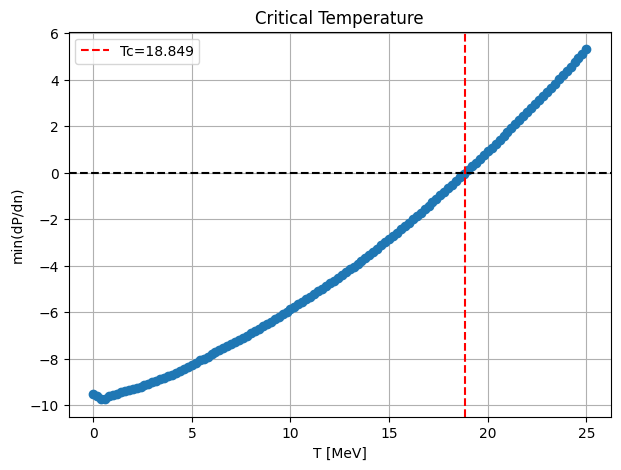

In [46]:
plt.figure(figsize=(7,5))

plt.plot(
    results["T"],
    results["min_dPdn"],
    "o-"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.axvline(
    Tc,
    color="red",
    linestyle="--",
    label=f"Tc={Tc:.3f}"
)

plt.xlabel("T [MeV]")
plt.ylabel("min(dP/dn)")
plt.title("Critical Temperature")
plt.legend()
plt.grid()
plt.show()

### Extracting $\delta$

delta  = 2.7021
stderr = 0.0573
R^2    = 0.9648


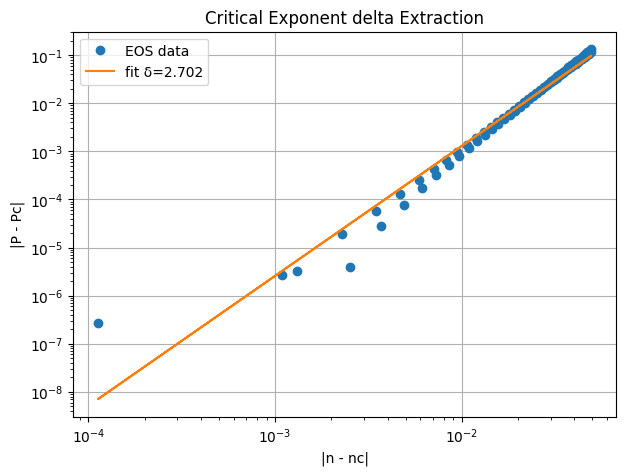

In [47]:
Tc = 18.84855866577679
nc = 0.0688
Pc = 0.39378748357168475

T1 = 18.8
T2 = 19.0

df1 = df[df["T [MeV]"] == T1].sort_values("n_B [1/fm3]")
df2 = df[df["T [MeV]"] == T2].sort_values("n_B [1/fm3]")

n1 = df1["n_B [1/fm3]"].values
P1 = df1["p [MeV/fm3]"].values

n2 = df2["n_B [1/fm3]"].values
P2 = df2["p [MeV/fm3]"].values

# common density grid
n_vals = np.linspace(max(n1.min(), n2.min()), min(n1.max(), n2.max()), 200)

# interpolate in temperature to Tc
alpha = (Tc - T1) / (T2 - T1)

# P(n,T_c) - new EOS at T_c
P_Tc = (1 - alpha) * np.interp(n_vals, n1, P1) + alpha * np.interp(n_vals, n2, P2)

x = np.abs(n_vals - nc)
y = np.abs(P_Tc - Pc)

mask = (x > 0) & (y > 0)

x = x[mask]
y = y[mask]

# choose points close to critical region
fit_mask = x < 0.05

x_fit = x[fit_mask]
y_fit = y[fit_mask]

logx = np.log(x_fit)
logy = np.log(y_fit)

slope, intercept, r, p, delta_err = linregress(logx, logy)

delta = slope

print("================================")
print(f"delta  = {delta:.4f}")
print(f"stderr = {delta_err:.4f}")
print(f"R^2    = {r**2:.4f}")
print("================================")

plt.figure(figsize=(7,5))

plt.loglog(x_fit, y_fit, 'o', label="EOS data")
plt.loglog(
    x_fit,
    np.exp(intercept)*x_fit**delta,
    label=f"fit δ={delta:.3f}"
)

plt.xlabel("|n - nc|")
plt.ylabel("|P - Pc|")
plt.legend()
plt.title("Critical Exponent delta Extraction")
plt.grid(True)
plt.show()

In [48]:
from scipy.stats import linregress

windows = [0.1, 0.09, 0.07, 0.05, 0.03, 0.02, 0.01, 0.009, 0.005, 0.003, 0.001]

print(f"{'|n-n_c|':>10} {'delta':>10} {'points':>10}")

for w in windows:

    mask = (x < w) & (x > 0) & (y > 0)

    if np.sum(mask) < 5:
        continue

    logx = np.log(x[mask])
    logy = np.log(y[mask])

    slope, intercept, _, _, _ = linregress(logx, logy)

    print(
        f"{w:10.4f}"
        f"{slope:10.3f}"
        f"{np.sum(mask):10d}"
    )

   |n-n_c|      delta     points
    0.1000     2.792       140
    0.0900     2.786       132
    0.0700     2.773       115
    0.0500     2.702        83
    0.0300     2.553        50
    0.0200     2.387        33
    0.0100     2.022        17
    0.0090     1.940        15
    0.0050     1.553         9
    0.0030     1.103         5


to do:
- [ ] how do I determine which window is ideal for the best delta?
- [ ] do the stat stuff for delta and get mean, std deviation etc.

### Extracting $\beta$

In [49]:
from scipy.interpolate import CubicSpline
from scipy.optimize import root

results = []

for T in temps:

    if T>17: 
        sub = (
            df[df["T [MeV]"] == T]
            .sort_values("n_B [1/fm3]")
        )
    
        n = sub["n_B [1/fm3]"].values
        f = sub["f [MeV/fm3]"].values
        mu = sub["mu_B [MeV]"].values

        f_spline = CubicSpline(n, f)
        mu_spline = CubicSpline(n, mu)
    
        def equations(x):
    
            ng, nl = x
    
            # forbid collapse
            if nl - ng < 1e-6:
                return [1e6, 1e6]
    
            mug = mu_spline(ng)
            mul = mu_spline(nl)
    
            fg = f_spline(ng)
            fl = f_spline(nl)
    
            secant = (fl - fg)/(nl - ng)
    
            eq1 = mug - mul
            eq2 = mug - secant
    
            return [eq1, eq2]
    
        guess = [
            n.min() + 0.2*(nc - n.min()),
            nc + 0.2*(n.max() - nc)
        ]
    
        sol = root(
            equations,
            guess
        )
    
        if not sol.success:
            continue
    
        ng, nl = sol.x
    
        err = np.linalg.norm(equations([ng, nl]))
    
        results.append([
            T,
            ng,
            nl,
            nl-ng,
            err
        ])
results = pd.DataFrame(
    results,
    columns=[
        "T",
        "n_gas",
        "n_liq",
        "delta_n",
        "error"
    ]
)

print(results)

      T     n_gas     n_liq   delta_n         error
0  17.2  0.035373  0.104610  0.069237  7.298319e-12
1  17.4  0.037338  0.102564  0.065226  4.608268e-13
2  17.6  0.039504  0.100376  0.060872  1.065814e-14
3  17.8  0.041934  0.098021  0.056088  1.214971e-11
4  18.0  0.044728  0.095465  0.050737  1.816681e-11
5  18.2  0.048094  0.092662  0.044568  1.299471e-11
6  18.4  0.052628  0.089527  0.036900  3.169715e-11


beta = 0.4818173710494044
stderr = 0.004287050139359186
R² = 0.9996043143096651


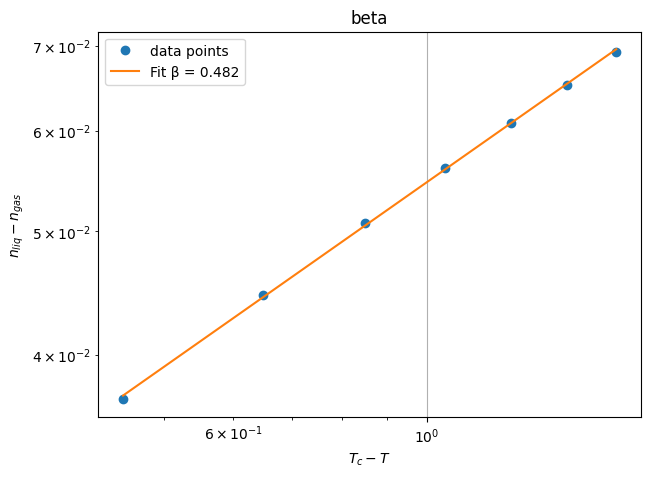

In [50]:
fit_df = results[
    (results["T"] < Tc)
]

x = Tc - fit_df["T"].values
y = fit_df["delta_n"].values

mask = (x > 0) & (y > 0)

logx = np.log(x[mask])
logy = np.log(y[mask])

beta, intercept, r, p, beta_err = linregress(
    logx,
    logy
)

print("================================")
print("beta =", beta)
print("stderr =", beta_err)
print("R² =", r**2)
print("================================")

plt.figure(figsize=(7,5))

plt.loglog(
    x,
    y,
    'o',
    label="data points"
)

plt.loglog(
    np.sort(x),
    np.exp(intercept)*np.sort(x)**beta,
    label=f"Fit β = {beta:.3f}"
)

plt.xlabel(r"$T_c - T$")
plt.ylabel(r"$n_{liq}-n_{gas}$")
plt.title("beta")
plt.grid(True)
plt.legend()

plt.show()

### Extracting $\gamma$

In [51]:
kappa_results = []

for T in temps:

    if T > Tc:
        
        sub = df[df["T [MeV]"] == T].sort_values("n_B [1/fm3]")
    
        n = sub["n_B [1/fm3]"].values
        P = sub["p [MeV/fm3]"].values
    
        dPdn = np.gradient(P, n)
    
        valid = np.abs(dPdn) > 1e-6
    
        n = n[valid]
        dPdn = dPdn[valid]
    
        # pick point closest to critical density nc
        idx = np.argmin(np.abs(n - nc))
    
        deriv = dPdn[idx]
        n0 = n[idx]
    
        kappa_T = 1.0 / (n0 * deriv)
    
        kappa_results.append([T, kappa_T])

kappa_df = pd.DataFrame(kappa_results, columns=["T", "kappa_T"])

gamma  = 1.0412
stderr = 0.0033
R^2    = 0.9997


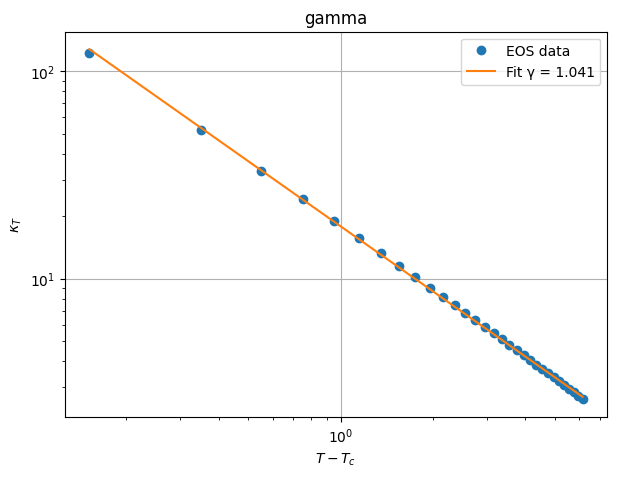

In [52]:
x = kappa_df["T"].values - Tc
y = kappa_df["kappa_T"].values

mask = (x > 0) & (y > 0)

logx = np.log(x[mask])
logy = np.log(y[mask])

slope, intercept, r, p, gamma_err = linregress(logx, logy)

gamma = -slope

print("================================")
print(f"gamma  = {gamma:.4f}")
print(f"stderr = {gamma_err:.4f}")
print(f"R^2    = {r**2:.4f}")
print("================================")

plt.figure(figsize=(7,5))

plt.loglog(
    x[mask],
    y[mask],
    'o',
    label="EOS data"
)

xx = np.sort(x[mask])

plt.loglog(
    xx,
    np.exp(intercept)*xx**slope,
    label=f"Fit γ = {gamma:.3f}"
)

plt.xlabel(r"$T - T_c$")
plt.ylabel(r"$\kappa_T$")
plt.title("gamma")
plt.grid(True)
plt.legend()
plt.show()

### Extracting $\alpha$

In [53]:
n_target = nc

e_vals = []
T_vals = []

for T in temps:
    if T>Tc:
        temp_slice = df[df["T [MeV]"] == T]
    
        n = temp_slice["n_B [1/fm3]"].values
        e = temp_slice["e [MeV/fm3]"].values
    
        idx = np.argmin(np.abs(n - n_target))
    
        e_vals.append(e[idx])
        T_vals.append(T)

e_vals = np.array(e_vals)
T_vals = np.array(T_vals)

Cv = np.gradient(e_vals, T_vals)

alpha  = -0.039061
stderr = 0.004603
R^2    = 0.712864


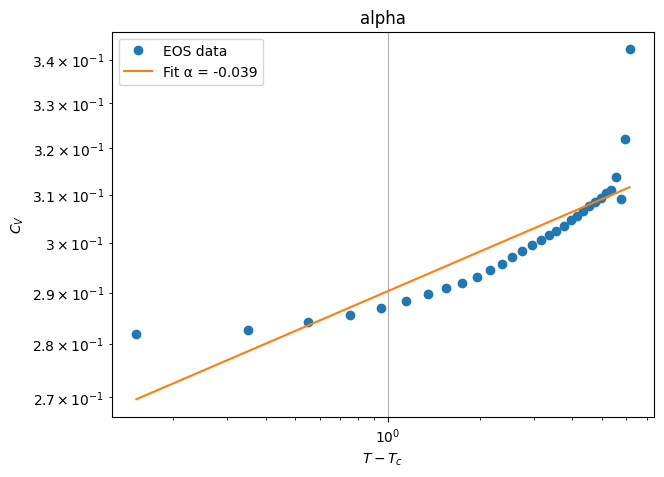

In [54]:
x = T_vals - Tc
y = Cv

logx = np.log(x)
logy = np.log(y)

slope, intercept, r, p, alpha_err = linregress(
    logx,
    logy
)

alpha = -slope

print("======================")
print(f"alpha  = {alpha:.6f}")
print(f"stderr = {alpha_err:.6f}")
print(f"R^2    = {r**2:.6f}")
print("======================")

plt.figure(figsize=(7,5))

plt.loglog(
    x,
    y,
    'o',
    label="EOS data"
)

xx = np.sort(x)

plt.loglog(
    xx,
    np.exp(intercept)*xx**slope,
    label=f"Fit α = {alpha:.3f}"
)

plt.xlabel(r"$T-T_c$")
plt.ylabel(r"$C_V$")
plt.title("alpha")
plt.grid(True)
plt.legend()

plt.show()

### Critical Exponents

In [55]:
print("CRITICAL EXPONENTS")
print()

print(f"{'Extracted Value':>24} {'Expected Value':>24}")

print(f"δ = {delta:.6f} ± {delta_err:.6f} {3:>25}")
print(f"β = {beta:.6f} ± {beta_err:.6f} {0.5:>25}")
print(f"γ = {gamma:.6f} ± {gamma_err:.6f} {1:>25}")
print(f"α = {alpha:.6f} ± {alpha_err:.6f} {0:>24}")

CRITICAL EXPONENTS

         Extracted Value           Expected Value
δ = 2.702090 ± 0.057335                         3
β = 0.481817 ± 0.004287                       0.5
γ = 1.041208 ± 0.003346                         1
α = -0.039061 ± 0.004603                        0
